In [98]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
conn = sqlite3.connect("/Users/laksh/OneDrive/Documents/Projects/Supervised Learning/Vendor_Invoice_Intelligence/data/inventory.db")
tables = pd.read_sql_query("select name from sqlite_master where type = 'table'",conn)

In [100]:
tables['name']

0          purchases
1    purchase_prices
2     vendor_invoice
3    begin_inventory
4      end_inventory
Name: name, dtype: object

In [101]:
for table in tables['name']:
    print('Table name',table)
    df = pd.read_sql_query(f"select *from {table} limit 5",conn)
    display(df)

Table name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [102]:
purcharse_df = pd.read_sql_query("select p.PONumber,count(distinct Brand) as total_brands,sum(p.Quantity) as total_item_quantity,sum(p.Dollars) as total_item_dollars,avg(julianday(p.ReceivingDate)-julianday(p.PODate)) as avg_receiving_delay   from purchases p group by p.PONumber",conn)

In [103]:
pd.read_sql_query("select vi.Quantity as invoice_quantity, vi.Dollars as invoice_dollars, vi.Freight, (julianday(vi.InvoiceDate)-julianday(vi.PODate)) as days_po_to_invoice, (julianday(vi.PayDate)-julianday(vi.InvoiceDate)) as days_to_pay from vendor_invoice vi",conn)

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,6,214.26,3.47,14.0,43.0
1,15,140.55,8.57,16.0,45.0
2,5,106.60,4.61,16.0,38.0
3,10100,137483.78,2935.20,23.0,24.0
4,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...
5538,90,1563.00,8.60,16.0,35.0
5539,4617,37300.48,186.50,18.0,39.0
5540,9848,202815.78,932.95,11.0,33.0
5541,24747,149007.56,819.54,14.0,36.0


In [104]:
df=pd.read_sql_query("""
with purchase_agg as(
    select p.PONumber,
    count(distinct Brand) as total_brands,
    sum(p.Quantity) as total_item_quantity,
    sum(p.Dollars) as total_item_dollars,
    avg(julianday(p.ReceivingDate)-julianday(p.PODate)) as avg_receiving_delay   
   from purchases p group by p.PONumber
)
select
    vi.PONumber,
    vi.Quantity as invoice_quantity, 
    vi.Dollars as invoice_dollars, vi.Freight, 
    (julianday(vi.InvoiceDate)-julianday(vi.PODate)) as days_po_to_invoice, 
    (julianday(vi.PayDate)-julianday(vi.InvoiceDate)) as days_to_pay,
    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars,
    pa.avg_receiving_delay
    from vendor_invoice vi
    left join purchase_agg pa on vi.PONumber = pa.PONumber
""",conn)

In [105]:
df

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541


In [106]:
df.isna().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5543 entries, 0 to 5542
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PONumber             5543 non-null   int64  
 1   invoice_quantity     5543 non-null   int64  
 2   invoice_dollars      5543 non-null   float64
 3   Freight              5543 non-null   float64
 4   days_po_to_invoice   5543 non-null   float64
 5   days_to_pay          5543 non-null   float64
 6   total_brands         5543 non-null   int64  
 7   total_item_quantity  5543 non-null   int64  
 8   total_item_dollars   5543 non-null   float64
 9   avg_receiving_delay  5543 non-null   float64
dtypes: float64(6), int64(4)
memory usage: 433.2 KB


In [108]:
def create_invoice_risk_label(row):
    if(abs(row["invoice_dollars"] - row["total_item_dollars"]) >5):
        return 1
    if row["avg_receiving_delay"]>10:
        return 1
    return 0
df['flag_invoice'] = df.apply(create_invoice_risk_label,axis=1)
df['flag_invoice'].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice', ylabel='count'>

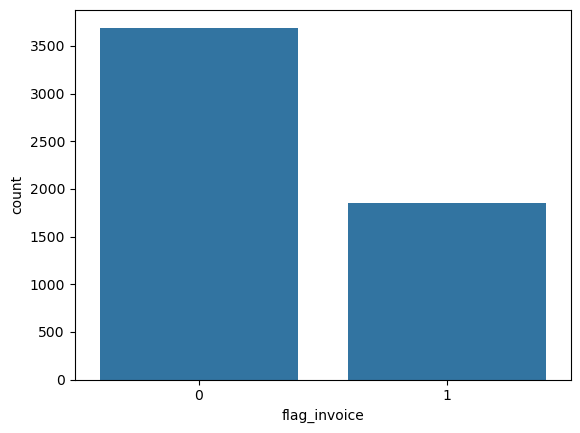

In [109]:
sns.barplot(df['flag_invoice'].value_counts())

In [110]:
flagged = df[df['flag_invoice']==1]
normal = df[df['flag_invoice']==0]

In [111]:
significant_features = []
non_significant_features =[]
results = []

In [112]:
df.columns

Index(['PONumber', 'invoice_quantity', 'invoice_dollars', 'Freight',
       'days_po_to_invoice', 'days_to_pay', 'total_brands',
       'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay',
       'flag_invoice'],
      dtype='object')

In [113]:
metrics = ['invoice_quantity','invoice_dollars','Freight','days_po_to_invoice','days_to_pay','total_brands','total_item_quantity','total_item_dollars','avg_receiving_delay']

In [114]:
from scipy.stats import ttest_ind
for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()
    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var = False
    )
    if p_value <0.05:
        significant_features.append(metric)
        results.append({
        "metric":metric,
        "flagged_mean": flagged_mean.round(2),
        "normal_mean": normal_mean.round(2),
        "p_value": p_value.round(3)
    })
    else:
        non_significant_features.append(metric)
        print(metric)
        print({
            "metric":metric,
            "flagged_mean": flagged_mean.round(2),
            "normal_mean": normal_mean.round(2),
            "p_value": p_value.round(3)
        })

days_to_pay
{'metric': 'days_to_pay', 'flagged_mean': np.float64(35.42), 'normal_mean': np.float64(35.49), 'p_value': np.float64(0.692)}
total_brands
{'metric': 'total_brands', 'flagged_mean': np.float64(42.29), 'normal_mean': np.float64(40.82), 'p_value': np.float64(0.508)}


In [115]:
non_significant_features

['days_to_pay', 'total_brands']

In [116]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [117]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'invoice_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'Freight',
  'flagged_mean': np.float64(334.02),
  'normal_mean': np.float64(276.89),
  'p_value': np.float64(0.008)},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': np.float64(17.23),
  'normal_mean': np.float64(16.02),
  'p_value': np.float64(0.0)},
 {'metric': 'total_item_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'total_item_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'avg_receiving_delay',
  'flagged_mean': np.float64(8.47),
  'normal_mean': np.float64(7.27),
  'p_value': np.float64(0.0)}]

In [118]:

X = df[[
    'invoice_quantity', 'invoice_dollars', 'Freight', 
    'days_po_to_invoice', 'total_brands', 
    'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay'
]]

y = df['flag_invoice'] 

In [119]:
df.head()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay,flag_invoice
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000,1
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333,1
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000,0
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130,1
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809,0


In [120]:
y

0       1
1       1
2       0
3       1
4       0
       ..
5538    1
5539    1
5540    1
5541    1
5542    1
Name: flag_invoice, Length: 5543, dtype: int64

In [121]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size = 0.2)

In [122]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [123]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [124]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,accuracy_score

In [125]:
lr = LogisticRegression()
lr.fit(X_train,y_train)

dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)

rf = RandomForestClassifier()
rf.fit(X_train,y_train)

RandomForestClassifier()

In [126]:
models = lr, dt, rf

In [127]:
for model in models:
    y_pred = model.predict(X_test)
    print(f" {model.__class__.__name__}\n{classification_report(y_test, y_pred)}")
    print('Accuracy',accuracy_score(y_test,y_pred))

 LogisticRegression
              precision    recall  f1-score   support

           0       0.74      0.93      0.82       725
           1       0.73      0.39      0.51       384

    accuracy                           0.74      1109
   macro avg       0.74      0.66      0.67      1109
weighted avg       0.74      0.74      0.71      1109

Accuracy 0.739404869251578
 DecisionTreeClassifier
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       725
           1       0.94      0.90      0.92       384

    accuracy                           0.95      1109
   macro avg       0.94      0.94      0.94      1109
weighted avg       0.95      0.95      0.95      1109

Accuracy 0.9458972046889089
 RandomForestClassifier
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       725
           1       1.00      0.87      0.93       384

    accuracy                           0.95      1109
   ma

In [129]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5, 
    scoring='accuracy',
    n_jobs=-1  # Uses all available processor cores for speed
)
grid_search.fit(X_train, y_train)
print(f"--- Hyperparameter Tuning Results ---")
print(f"Best Parameters found: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print(f"Test Set Accuracy with Best Model: {accuracy_score(y_test, y_pred_best):.4f}")

--- Hyperparameter Tuning Results ---
Best Parameters found: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best Cross-Validation Accuracy: 0.9626
Test Set Accuracy with Best Model: 0.9549
